# Day5: 인공지능 컴퓨터 비젼

## 학습 내용
1. Roboflow 사용법
2. Yolov11을 이용한 객체분할 (instance segmentation) 학습

In [4]:
# !pip install -qU ultralytics roboflow

import os
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt

import ultralytics
import yaml

## 1. YOLO 객체 분할: Can glass data

In [1]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="HHKXlDyiIfBO33SpID7d")
project = rf.workspace("firedetection-ysypi").project("recycle-lanvw")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Recycle-1 in yolov11:: 100%|██████████| 36/36 [00:00<00:00, 1504.11it/s]


### 압축 출기

### Yolo v11 객체분할 모델 불러오기

In [ ]:
# Load a model

model = ultralytics.YOLO("yolo11n-seg.pt")  # load a pretrained model (recommended for training)

Transferred 499/561 items from pretrained weights


### Can glass segmentation yaml 파일 만들기

In [ ]:
data = {
    'train' : '/Recycle-1/train/images', # 'train': 훈련 이미지 파일들이 위치한 디렉토리 경로
    'val' : '/Recycle-1/train/images', # 'val': 검증 이미지 파일들이 위치한 디렉토리 경로
    'test' : '/Recycle-1/train/images', # 'test': 테스트 이미지 파일들이 위치한 디렉토리 경로 (선택 사항)
    'names' : ["can", "glass"], # 클래스 이름 목록 (알파벳 순서에 따라 ID가 할당됨, 0: can, 1: glass)
    'nc' : 2
}

# 'can-glass/data.yaml' 파일을 쓰기 모드('w')로 열고 파일 객체를 'f'로 지정
with open('can-glass/data.yaml', 'w') as f:
    yaml.dump(data, f)

### Yolo v11 can-glass 객체분할 모델 학습

In [ ]:
# Train the model
results = model.train(data='./Recycle-1/data.yaml', epochs=20, patience = 5, imgsz=640)

# 훈련 지표 (Training Metrics)
# GPU_mem (0.516G): 현재 모델이 사용하고 있는 GPU(그래픽 처리 장치) 메모리 양.
# box_loss (1.365): 바운딩 박스 회귀와 관련된 손실 값. 예측된 바운딩 박스가 실제 바운딩 박스와 위치, 너비, 높이 면에서 얼마나 잘 일치하는지를 정량화
# cls_loss (1.328): 분류 손실. 모델이 탐지된 각 객체에 대해 올바른 클래스를 얼마나 잘 예측하는지를 측정
# dfl_loss (1.056): DFL(Distribution Focal Loss)의 약자입니다. 이 손실은 현대 객체 탐지 모델(일부 YOLO 버전과 같은)에서 모델이 분류하기 어려운 예시에 집중
# Instances (1): 현재 반복(iteration)에서 처리된 인스턴스 또는 배치(batch)의 수
# Size (256): 모델이 처리하는 입력 이미지의 크기(예: 256x256 픽셀)입니다.

# 평가 지표 (Evaluation Metrics)
# Images (2047): 검증/평가 데이터셋에 있는 총 이미지 수
# Instances (2194): 검증/평가 데이터셋의 모든 이미지에 걸쳐 있는 실제 객체 인스턴스(바운딩 박스)의 총 수
# Box (P: Precision, R: Recall, mAP50, mAP50-95):
# P (Precision, 정밀도): 모델이 '있다'고 예측한 것 중 실제로 맞는 것의 비율
# R (Recall, 재현율): 실제로 있어야 할 객체 중 모델이 얼마나 많이 찾아냈는지를 나타냄
# mAP50 (평균 정밀도, IoU 0.5): IoU(Intersection over Union, 겹침 영역 비율) 임계값을 0.5로 설정했을 때의 평균 정밀도
# mAP50-95 (평균 정밀도, IoU 0.5~0.95): IoU 임계값을 0.5부터 0.95까지 0.05 단위로 증가시키면서 계산한 평균 정밀도들의 평균

New https://pypi.org/project/ultralytics/8.3.173 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.172 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/can-glass/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/segment/train2/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, n

train: Scanning /content/can-glass/train/labels.cache... 84 images, 0 backgrounds, 0 corrupt: 100%|██████████| 84/84 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 236.0±102.4 MB/s, size: 16.7 KB)


val: Scanning /content/can-glass/train/labels.cache... 84 images, 0 backgrounds, 0 corrupt: 100%|██████████| 84/84 [00:00<?, ?it/s]


...

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  67%|██████▋   | 2/3 [00:00<00:00,  2.27it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.35it/s]


                   all         84         84      0.994          1      0.995      0.953      0.994          1      0.995      0.972
                   can         45         45       0.99          1      0.995      0.953       0.99          1      0.995      0.984
                 glass         39         39      0.999          1      0.995      0.953      0.999          1      0.995       0.96
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs/segment/train


### Yolo v11 Can-glass 객체분할 학습된 모델 불러오기

In [ ]:
# Ultralytics 라이브러리의 YOLO 클래스를 사용하여 지정된 경로에서 모델을 로드
model_path = os.path.join(os.getcwd(), 'seg_best.pt')
model = ultralytics.YOLO(model_path)

In [ ]:
# 'model' 객체를 사용하여 객체 감지(Inference)를 실행
# source: 감지 대상 이미지 파일들이 들어있는 디렉토리 경로를 지정
#         이 디렉토리의 모든 이미지에 대해 감지가 수행
# save: 감지 결과(바운딩 박스가 그려진 이미지)를 디스크에 저장하도록 지시
# 'result' 변수에는 감지 결과에 대한 상세 정보(예: 박스 좌표, 신뢰도 등)가 담긴 객체 목록이 할당
test_path = os.path.join(os.getcwd(), 'Recycle-1/train/images')
results = model(source = test_path, save = True)


image 1/8 d:\OneDrive\Documents\lecture_2019\Academy\4_DL\2519__KD\course_ipynb\day5\Recycle-1\train\images\bandicam-2019-11-03-19-33-40-268_jpg.rf.777599863df1967e9085a98572209359.jpg: 640x640 1 can, 39.5ms
image 2/8 d:\OneDrive\Documents\lecture_2019\Academy\4_DL\2519__KD\course_ipynb\day5\Recycle-1\train\images\bandicam-2019-11-03-19-37-35-705_jpg.rf.0b9ad3c53e34e73186c602b483c40a47.jpg: 640x640 1 can, 39.2ms
image 3/8 d:\OneDrive\Documents\lecture_2019\Academy\4_DL\2519__KD\course_ipynb\day5\Recycle-1\train\images\bandicam-2019-11-03-19-43-32-261_jpg.rf.6ba9e79b450571c33bc357e323482654.jpg: 640x640 1 can, 39.7ms
image 4/8 d:\OneDrive\Documents\lecture_2019\Academy\4_DL\2519__KD\course_ipynb\day5\Recycle-1\train\images\bandicam-2019-11-03-20-37-04-491_jpg.rf.c0f867ec26932e2fc3839a19f7456ab9.jpg: 640x640 1 glass, 11.6ms
image 5/8 d:\OneDrive\Documents\lecture_2019\Academy\4_DL\2519__KD\course_ipynb\day5\Recycle-1\train\images\bandicam-2019-11-03-20-37-09-838_jpg.rf.5b07b12ae7708598c

### Yolo v11 Can-glass 객체분할 학습된 모델로 부터 마스트 추출하기

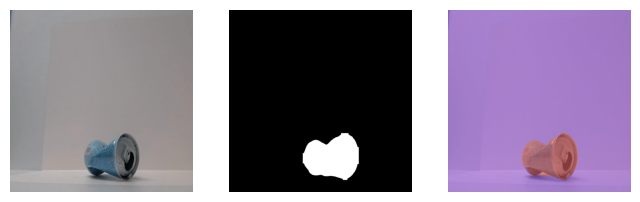

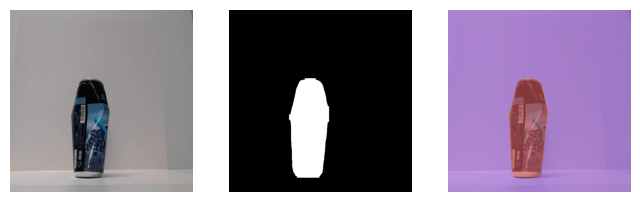

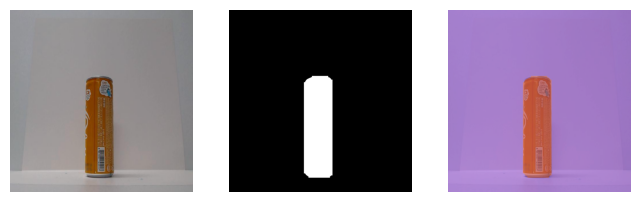

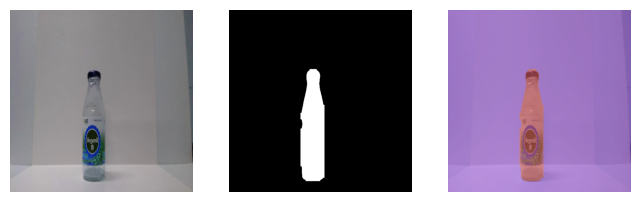

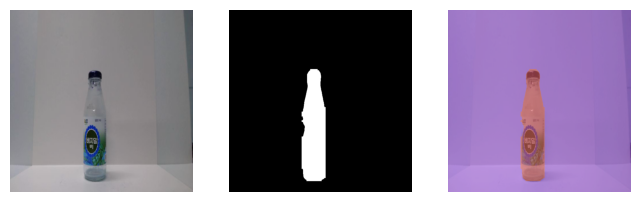

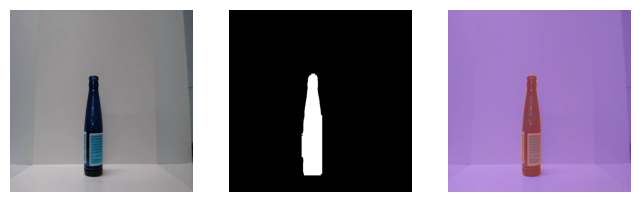

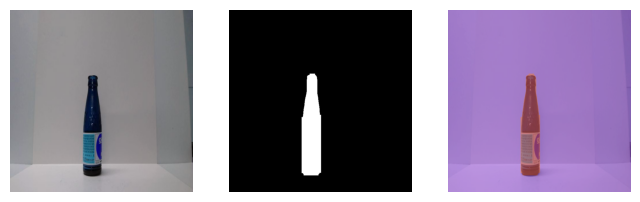

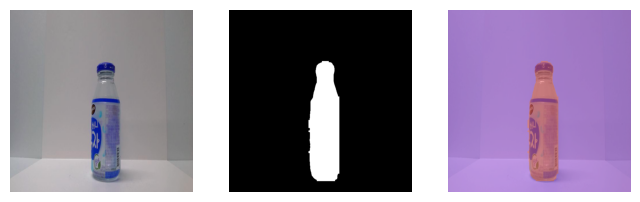

In [8]:
# from PIL import Image
# import cv2
import matplotlib.pyplot as plt

for result in results:
    image = result[0].orig_img
    mask = result[0].masks.data[0].cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize = (8,4))
    ax[0].imshow(image)
    ax[0].axis("off")
    ax[1].imshow(mask, cmap = "gray")
    ax[1].axis("off")
    ax[2].imshow(image, alpha = 0.7)
    ax[2].imshow(mask, alpha = 0.3, cmap = "rainbow")
    ax[2].axis("off")
    plt.show()
